In [16]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
from Code import cycle_process, xtb_process, logfile_process, main, model_train
import glob, shutil, os 
import numpy as np
import pandas as pd
from rdkit import Chem
from tqdm import tqdm

diene: means 4π

ene: means 2π

In [ ]:
# PRED_CSV_DIR = r"E:\work\Secondary_Selection\All_possible_DA_ZINC" # <- The dir you want to save the all combinations Result
# SMILES_DIR= r"E:\work\Secondary_Selection\Diene_Ene_Smiles" # <- The dir you want to save the Reactants Calculation Result
# CSV_FILE_DIR= r"Data/Iteration_Data"# <- The dir you want to save the Result
# QM_MAP = "Data/DFT_Result/Descriptors_Filter.pkl" # <- The dir you want to save the Descriptors

In [5]:
Chem.MolToSmiles(Chem.MolFromSmiles("O=C(NC)C1=NC=C(C(F)(F)F)NC1=O"))

'CNC(=O)c1ncc(C(F)(F)F)[nH]c1=O'

# 1. DFT Calculate the Reactants

In [ ]:
df = pd.read_csv(r"E:\work\Secondary_Selection\Diene_Ene_Smiles\Descriptors_appeared.csv")
new_df = df[['Smiles', 'Smiles_Id']]
new_df.drop_duplicates(subset=['Smiles'], keep='first', inplace=True)
new_df.to_csv(r"E:\work\Secondary_Selection\Diene_Ene_Smiles\all_smiles.csv", index=False)

In [20]:
PRED_CSV_DIR = r"E:\work\Secondary_Selection\All_possible_DA_ZINC"
SMILES_DIR= r"E:\work\Secondary_Selection\Diene_Ene_Smiles2"
OLD_SMILES_DIR = r"E:\work\Secondary_Selection\Diene_Ene_Smiles"
CSV_FILE_DIR= r"../Data/Iteration_Data"
QM_MAP = CSV_FILE_DIR + "/" + "all_property_detailSterimol_witharea.pkl" # Copy from smiles_csv

In [21]:
target_dir = SMILES_DIR     
csv_dirs = [r'E:\work\Secondary_Selection\s-TCO.csv']
# csv_dirs = ["../Data/ZINC_Data/all_selected_smiles2.csv"]                   # <- The dir you saved the reactants

In [22]:
# Stablization
for csv_dir in csv_dirs:
    df = pd.read_csv(csv_dir)
    for row_id, row in df.iterrows():
        row['Diene'] = Chem.MolToSmiles(Chem.MolFromSmiles(row['Diene']))
        row['Ene'] = Chem.MolToSmiles(Chem.MolFromSmiles(row['Ene']))
        df.loc[row_id] = row
    df.to_csv(csv_dir, index=False)

In [11]:
csv_dirs

['E:\\work\\Secondary_Selection\\s-TCO.csv']

In [23]:
main.collect_smiles_file(csv_dirs = csv_dirs, root_dir=target_dir, sugan=False, old_smiles_csv = OLD_SMILES_DIR + "/" + 'all_smiles.csv')
xtb_process.shift_to_parra(target_dir + "/first_xtb")

In [8]:
xtb_process.shift_to_parra(target_dir + "/first_xtb")

In [84]:
main.smiles_DFT_calc(target_dir, rmsd_limit=1)

In [19]:
main.error_improve(target_dir, "mol_dft")

100%|██████████| 8/8 [00:00<00:00, 25.72it/s]

E:\work\Secondary_Selection\Diene_Ene_Smiles2/mol_dft\smilesid_18746_0002.log didn't run successful
E:\work\Secondary_Selection\Diene_Ene_Smiles2/mol_dft\smilesid_18746_0002.log 应该是没跑完
E:\work\Secondary_Selection\Diene_Ene_Smiles2/mol_dft\smilesid_18746_0002.log. Error Reason is link 9999 or unfinished.


In [85]:
main.SPE_DFT_calc(target_dir, save_chk=False)

100%|██████████| 2/2 [00:00<00:00, 33.05it/s]


In [41]:
main.error_improve(target_dir, "mol_dft_eng")

100%|██████████| 12/12 [00:00<00:00, 1000.03it/s]


In [86]:
main.SPE_DFT_calc(target_dir, save_chk=False, opt_name = "mol_dft", eng_name = "mol_dft_eng_solvent", method="b3lyp/6-311+g(d,p) em=gd3bj scrf=(smd, solvent=water)")

100%|██████████| 2/2 [00:00<00:00, 39.98it/s]


In [40]:
main.error_improve(target_dir, "mol_dft_eng_solvent")

100%|██████████| 12/12 [00:00<00:00, 856.88it/s]


In [49]:
main.SPE_DFT_calc(target_dir, save_chk=False, opt_name = "mol_dft", eng_name = "mol_dft_eng_solvent2", method="b3lyp/6-311+g(d,p) em=gd3bj scrf=(smd, solvent=1,4-dioxane)")

100%|██████████| 5/5 [00:00<00:00, 79.37it/s]


In [87]:
main.smiles_result_analysis(target_dir)

2it [00:00, 18.04it/s]


In [88]:
new_smiles_csv = pd.read_csv(SMILES_DIR + "/" + "all_smiles.csv")
old_smiles_csv = pd.read_csv(OLD_SMILES_DIR + "/" + "all_smiles.csv")
final_smiles_csv = pd.concat([old_smiles_csv, new_smiles_csv])
final_smiles_csv.to_csv(OLD_SMILES_DIR + "/" + "all_smiles.csv", index=False)

# 2. Get Descriptors for Reactants

In [ ]:
bo_df = pd.read_csv(r"E:\work\Secondary_Selection\All_possible_DA_ZINC_BO\all_reported_BO_One.csv")
di_df = pd.read_csv(r"Data\DFT_Result\Full_Space.csv")
all_appeared_reactant_ids = set(bo_df['Diene_Index'].tolist() + bo_df['Ene_Index'].tolist() + di_df['Diene_Index'].tolist() + di_df['Ene_Index'].tolist())
smiles_dict=pd.read_csv(SMILES_DIR + "/" + "all_smiles.csv")
new_smiles_csv = smiles_dict[smiles_dict['Index'].isin(np.sort(list(all_appeared_reactant_ids)))]
new_smiles_csv.to_csv(SMILES_DIR + "/" + "all_smiles_appeared.csv", index=False)

In [50]:
conf_id_key = {row['Index']: row['Stable_conf_id'] for _, row in new_smiles_csv.iterrows()}

In [4]:
ALL_PROPERTIES_diene = ["diene_charge_a", "diene_charge_b", "diene_charge_c", "diene_charge_d",
    "diene_max_neighbor_charge", "diene_min_neighbor_charge", "diene_max_charge", "diene_min_charge", "bond_1", "bond2", "bond3", "distance_ad",
    "angle_a_cos", "angle_b_cos", "diene_max_angle_cos", "diene_min_angle_cos", "torsion",
    "diene_homo-1", "diene_homo", "diene_lumo", "diene_lumo+1", "diene_dipole", 
    "max_diene_L", "min_diene_L", "max_diene_B1", "min_diene_B1", "max_diene_B5", "min_diene_B5"]
ALL_PROPERTIES_ene = ["ene_charge_e", "ene_charge_f", "ene_max_neighbor_charge", "ene_min_neighbor_charge", 
    "diene_max_charge", "diene_min_charge", "bond4", 
    "ene_max_angle_cos", "ene_min_angle_cos", "ene_homo-1", "ene_homo", "ene_lumo", "ene_lumo+1", 
    "ene_dipole", "max_ene_L", "min_ene_L", "max_ene_B1", "min_ene_B1", "max_ene_B5", "min_ene_B5"]

In [ ]:
smiles_dict=pd.read_csv(SMILES_DIR + "/" + "all_smiles.csv")
smiles_dir=SMILES_DIR
main.smiles_property_generate(file_name='Descriptors_appeared.csv', smiles_dict=smiles_dict, smiles_dir=smiles_dir)

In [52]:
conf_id_key = {row['Index']: row['Stable_conf_id'] for _, row in smiles_dict.iterrows()}

### Calculate SVO

In [48]:
new_des = ['diene_area_0', 'diene_area_1', 'diene_area_2', 'diene_area_3', 'diene_area_4', 'diene_area_5', 'diene_area_6', 'diene_area_7', 
'ene_area_0', 'ene_area_1', 'ene_area_2', 'ene_area_3', 'ene_area_4', 'ene_area_5', 'ene_area_6', 'ene_area_7', ]

In [54]:
idx

91673

In [55]:
df = pd.read_csv(SMILES_DIR + "/" + "Descriptors_appeared.csv")
all_properties = [[] for _ in range(len(new_des))]
mol_dir=SMILES_DIR
for idx, row in tqdm(df.iterrows()):
    smiles = row["Smiles"]
    smiles_id = row["Smiles_Id"]
    smiles_type = row['Type']
  
    title = row['Title']
    title = [int(each) for each in title.split()]
    mol = Chem.MolFromMolFile(mol_dir + '/mol/smilesid_%.5d.mol' % smiles_id, removeHs=False)

    conf_id = conf_id_key[smiles_id]
    target_log = SMILES_DIR + f"/mol_dft/smilesid_{smiles_id:05}_{conf_id:04}.log"
    log = logfile_process.Logfile(target_log)
    symbol_list = log.symbol_list
    positions = log.running_positions[-1]
    mol = xtb_process.xtb_to_mol(mol, [symbol_list], [positions], 1)
    if smiles_type == 'Diene':
        # try:
        for mol, atom_lists, tran_cis in cycle_process.change_position(mol, prop='diene', return_tran_cis=True):
            if atom_lists[0] == title[0] and atom_lists[-1] == title[1]:
                # result = [tran_cis]
                result = model_train.Calc_areas(mol, atom_lists)
                break
        assert len(result) == 8
        [all_properties[each].append(result[each]) for each in range(0,8)]
        [all_properties[each].append(np.nan) for each in range(8,16)]
        # except:
        #     print(smiles_id, title)
    else:
        for mol, atom_lists in cycle_process.change_position(mol, prop='dieno'):
            if atom_lists[0] == title[0] and atom_lists[-1] == title[1]:
                result = model_train.Calc_areas(mol, atom_lists)
                break
            if atom_lists[0] == title[1] and atom_lists[-1] == title[0]:
                result = model_train.Calc_areas(mol, atom_lists)
                result = [result[5], result[4], result[7], result[6], result[1], result[0], result[3], result[2]]
                break
        [all_properties[each].append(np.nan) for each in range(0,8)]
        [all_properties[each].append(result[each - 8]) for each in range(8,16)]
for each_new_des, all_property in zip(new_des, all_properties):
    df[each_new_des] = all_property
df.to_csv(SMILES_DIR + "/" + "Descriptors_appeared_.csv", index=False)

8543it [02:26, 56.25it/s] [15:13:40] Warning: molecule is tagged as 3D, but all Z coords are zero
[15:13:40] Warning: molecule is tagged as 3D, but all Z coords are zero
[15:13:40] Warning: molecule is tagged as 3D, but all Z coords are zero
[15:13:40] Warning: molecule is tagged as 3D, but all Z coords are zero
[15:13:40] Warning: molecule is tagged as 3D, but all Z coords are zero
21364it [06:47, 57.08it/s][15:18:00] Warning: molecule is tagged as 3D, but all Z coords are zero
[15:18:00] Warning: molecule is tagged as 3D, but all Z coords are zero
[15:18:00] Warning: molecule is tagged as 3D, but all Z coords are zero
[15:18:00] Warning: molecule is tagged as 3D, but all Z coords are zero
21371it [06:47, 59.98it/s][15:18:00] Warning: molecule is tagged as 3D, but all Z coords are zero
[15:18:00] Warning: molecule is tagged as 3D, but all Z coords are zero
21636it [06:51, 67.95it/s][15:18:05] Warning: molecule is tagged as 3D, but all Z coords are zero
[15:18:05] Warning: molecule is 

In [56]:
import pickle
smiles_dir = SMILES_DIR
property_dict=pd.read_csv(SMILES_DIR + "/" + "Descriptors_appeared_.csv")
# smiles_dict = 
target_map = {}
for idx in range(len(property_dict["Smiles"])):
    smiles_id = property_dict["Smiles_Id"][idx]
    type_name = property_dict["Type"][idx]
    if type_name == "Diene":
        type_id = 1
    elif type_name == "Ene":
        type_id = 0
    title = property_dict["Title"][idx]
    key = "%.5d %d " % (smiles_id, type_id) + title
    if type_id == 1:
        result = [property_dict[property][idx] for property in main.ALL_PROPERTIES_diene + new_des[:8]]
    elif type_id == 0:
        result = [property_dict[property][idx] for property in main.ALL_PROPERTIES_ene + new_des[8:]]

    target_map[key] = result
with open(smiles_dir + "/" + "Descriptors_appeared_.pkl", "wb") as f:
    pickle.dump(target_map, f)

# 3. Generate the All Cross-Combination Dataset with passed 4π and 2π

In [ ]:
smiles_dir=SMILES_DIR
smiles_csv_dir = SMILES_DIR + "/" + "all_smiles.csv"
target_dir = PRED_CSV_DIR
# target_dir = PRED_BO_CSV_DIR -> Just for Reported BO

In [ ]:
result_diene_csv = pd.read_csv(r"Data/ZINC_Data/target_diene_passed.csv")
result_ene_csv = pd.read_csv(r"Data/ZINC_Data/target_ene_passed.csv")
result_diene_csv = result_diene_csv.loc[~np.isnan(result_diene_csv['E/Hatree'].to_numpy())]
result_ene_csv = result_ene_csv.loc[~np.isnan(result_ene_csv['E/Hatree'].to_numpy())]
dienes = set(result_diene_csv["Index"].tolist())
enes = set(result_ene_csv["Index"].tolist())
len(dienes), len(enes)


In [ ]:
# Run It Just When You Generate All Cross-Combination of Reported Bioorthogonal Reactions
dienes = [5944, 18472, 11875, 18500, 12881]
enes = [18429, 18627, 18460, 18619, 18427, 18408, 11950, 18454, 18405,
        11936, 18502, 18611, 18425, 18583, 11955, 18612, 18420, 18457,
        18445, 18620, 18402, 18400, 18451, 11948, 18421, 18100, 18613,
        11932, 11933, 18450, 18558, 18423, 18424, 18447, 18453, 18403,
        18452, 18426]
# The Result are require from 

In [ ]:
smiles_dict = pd.read_csv(smiles_csv_dir)

all_smiles = smiles_dict["Smiles"].to_list()
all_smiles_ids = smiles_dict['Index'].to_list()
if not os.path.isdir(target_dir):
    os.mkdir(target_dir)
QM_MAP = smiles_dir + "/" + "all_property_detailSterimol_witharea.pkl"
with open(QM_MAP, "rb") as f:
    target_map = pickle.load(f)
def diene_with_multienes(diene_id, file_name=None):
    result_dict = {"Diene":{}, "Diene_Index":{}, "Ene":{}, "Ene_Index":{}, "Product":{}, "Unreverse":{}, "Title":{}, "Structure_Id":{}}
    result_dict_id = 0
    diene = all_smiles[all_smiles_ids.index(diene_id)]
    all_mols = []
    all_mols_name = []
    all_titles = []
    result_dir = target_dir + "/"
    if not os.path.isdir(result_dir):
        os.mkdir(result_dir)
    for ene_id in enes:
        ene = all_smiles[all_smiles_ids.index(ene_id)]
        diene_conf_id = smiles_dict["Stable_conf_id"][diene_id]
        ene_conf_id = smiles_dict["Stable_conf_id"][ene_id]

        diene_mol_dir = smiles_dir + '/mol/smilesid_%.5d.mol' % diene_id
        diene_mol = Chem.MolFromMolFile(diene_mol_dir, removeHs=False)
        diene_log_dir = smiles_dir + "/mol_dft_eng/smilesid_%.5d_%.4d.log" % (diene_id, diene_conf_id)
        diene_log = logfile_process.Logfile(diene_log_dir)
        atom_list = diene_log.symbol_list
        position = diene_log.first_atom_position
        diene_mol = xtb_process.xtb_to_mol(diene_mol, [atom_list], [position], 1)
        # Chem.AllChem.EmbedMultipleConfs(diene_mol, 50)
        assert len(diene_mol.GetConformers()) !=0

        ene_mol_dir = smiles_dir + '/mol/smilesid_%.5d.mol' % ene_id
        ene_mol = Chem.MolFromMolFile(ene_mol_dir, removeHs=False)
        ene_log_dir = smiles_dir + "/mol_dft_eng/smilesid_%.5d_%.4d.log" % (ene_id, ene_conf_id)
        ene_log = logfile_process.Logfile(ene_log_dir)
        atom_list = ene_log.symbol_list
        position = ene_log.first_atom_position
        ene_mol = xtb_process.xtb_to_mol(ene_mol, [atom_list], [position], 1)
        # Chem.AllChem.EmbedMultipleConfs(ene_mol, 50)
        assert len(ene_mol.GetConformers()) !=0
        molgroup = []
        # try:
        molgroup = cycle_process.react(dieno_mol = ene_mol, diene_mol = diene_mol,select_diene=0, FFopt=False)
    
        for structure_id, [eng, mol, title] in enumerate(molgroup):
            diene_atoma, diene_atomb, ene_atomc, ene_atomd, _, title_1 = [int(each) for each in title[:6]]
            diene_key = "%.5d %d %d %d" % (diene_id, 1, diene_atoma, diene_atomb)
            ene_key = "%.5d %d %d %d" % (ene_id, 0, ene_atomc, ene_atomd)
            if diene_key not in target_map.keys() or ene_key not in target_map.keys():
                continue
            Chem.SanitizeMol(mol)
            all_mols.append(mol)
            all_titles.append(title)
            product = Chem.MolToSmiles(mol)
            result_dict["Diene"][result_dict_id] = diene
            result_dict["Diene_Index"][result_dict_id] = diene_id
            result_dict["Ene"][result_dict_id] = ene
            result_dict["Ene_Index"][result_dict_id] = ene_id
            result_dict["Product"][result_dict_id] = product
            result_dict["Diene"][result_dict_id] = diene
            result_dict["Title"][result_dict_id] = " ".join([str(num) for num in title])
            result_dict["Structure_Id"][result_dict_id] = structure_id
            result_dict["Unreverse"][result_dict_id] = title[-1]
            result_dict_id += 1
        # except:
        #     pass
    if file_name == None:
        result_dict_name = result_dir + "Diene_Index_%.5d.csv" % diene_id
    else:
        result_dict_name = result_dir + "%s.csv" % file_name
    result_dict = pd.DataFrame(result_dict)
    result_dict.to_csv(result_dict_name, index=False)





In [ ]:
for diene in tqdm(dienes):
    diene_with_multienes(diene)

In [ ]:
def diene_with_self(diene_indexs, file_name=None):
    result_dict = {"Diene":{}, "Diene_Index":{}, "Ene":{}, "Ene_Index":{}, "Product":{}, "Unreverse":{}, "Title":{}, "Structure_Id":{}}
    result_dict_id = 0
    smiles_csv = pd.read_csv(SMILES_DIR + '/all_smiles.csv')
    smiles_id_dict = {row["Index"]: row["Smiles"] for row_id, row in smiles_csv.iterrows()}
    all_mols = []
    all_titles = []
    target_dir = r"G:\work\Secondary_Selection\All_possible_DA"
    result_dir = target_dir + "/"
    if not os.path.isdir(result_dir):
        os.mkdir(result_dir)
    for diene_id in diene_indexs:
        # try:
        smiles_dir=SMILES_DIR

        ene_id = diene_id
        diene = smiles_id_dict[diene_id]
        ene = diene
        diene_conf_id = smiles_csv["Stable_conf_id"][diene_id]
        ene_conf_id = smiles_csv["Stable_conf_id"][ene_id]
        if len(cycle_process.find_all_diene(Chem.MolFromSmiles(diene))) == 0:
            continue
        diene_mol_dir = smiles_dir + '/mol/smilesid_%.5d.mol' % diene_id
        diene_mol = Chem.MolFromMolFile(diene_mol_dir, removeHs=False)
        diene_log_dir = smiles_dir + "/mol_dft_eng/smilesid_%.5d_%.4d.log" % (diene_id, diene_conf_id)
        diene_log = logfile_process.Logfile(diene_log_dir)
        atom_list = diene_log.symbol_list
        position = diene_log.first_atom_position
        diene_mol = xtb_process.xtb_to_mol(diene_mol, [atom_list], [position], 1)
        # Chem.AllChem.EmbedMultipleConfs(diene_mol, 50)
        assert len(diene_mol.GetConformers()) !=0

        ene_mol_dir = smiles_dir + '/mol/smilesid_%.5d.mol' % ene_id
        ene_mol = Chem.MolFromMolFile(ene_mol_dir, removeHs=False)
        ene_log_dir = smiles_dir + "/mol_dft_eng/smilesid_%.5d_%.4d.log" % (ene_id, ene_conf_id)
        ene_log = logfile_process.Logfile(ene_log_dir)
        atom_list = ene_log.symbol_list
        position = ene_log.first_atom_position
        ene_mol = xtb_process.xtb_to_mol(ene_mol, [atom_list], [position], 1)
        # Chem.AllChem.EmbedMultipleConfs(ene_mol, 50)
        assert len(ene_mol.GetConformers()) !=0
        molgroup = []
        # try:
        molgroup = cycle_process.react(dieno_mol = ene_mol, diene_mol = diene_mol,select_diene=0, FFopt=False)
    
        for structure_id, [eng, mol, title] in enumerate(molgroup):
            Chem.SanitizeMol(mol)
            all_mols.append(mol)
            all_titles.append(title)
            product = Chem.MolToSmiles(mol)
            result_dict["Diene"][result_dict_id] = diene
            result_dict["Diene_Index"][result_dict_id] = diene_id
            result_dict["Ene"][result_dict_id] = ene
            result_dict["Ene_Index"][result_dict_id] = ene_id
            result_dict["Product"][result_dict_id] = product
            result_dict["Diene"][result_dict_id] = diene
            result_dict["Title"][result_dict_id] = " ".join([str(num) for num in title])
            result_dict["Structure_Id"][result_dict_id] = structure_id
            result_dict["Unreverse"][result_dict_id] = title[-1]
            result_dict_id += 1
            # except:
            #     pass
        # except:
        #     continue
    if file_name == None:
        result_dict_name = result_dir + "Diene_Index_%.5d.csv" % diene_id
    else:
        result_dict_name = result_dir + "%s.csv" % file_name
    result_dict = pd.DataFrame(result_dict)
    result_dict.to_csv(result_dict_name)

In [ ]:
diene_with_self(list(dienes | enes), file_name="diene_self")

# 4. DFT Calculation Reactions

In [4]:
target_dir = r"G:\work\Secondary_Selection\BO_Low_than_24_2"
smiles_dir = r"G:/work/Secondary_Selection/Diene_Ene_Smiles"
smiles_csv_dir = r"G:/work/Secondary_Selection/Diene_Ene_Smiles/all_smiles.csv"
reaction_file_dir = r"G:/work/Secondary_Selection/BO_LowThan_24_2.csv"
Result_csv = "Data/target_diene_ene_Result.csv"
Times = 1
acquire_title = False

In [24]:
target_dir = r"E:\work\Secondary_Selection\s-TCO"
smiles_dir = r"E:/work/Secondary_Selection/Diene_Ene_Smiles"
smiles_csv_dir = r"E:/work/Secondary_Selection/Diene_Ene_Smiles/all_smiles.csv"
reaction_file_dir = r"E:\work\Secondary_Selection\s-TCO.csv"
Result_csv = "../Data/Predict_DI/T705_Final_result.csv"
acquire_title = False

In [ ]:
target_dir = r"E:\work\All_BO_Prediction\BO_test_02"
smiles_dir = r"E:/work/Secondary_Selection/Diene_Ene_Smiles"
smiles_csv_dir = r"E:/work/Secondary_Selection/Diene_Ene_Smiles/all_smiles.csv"
reaction_file_dir = r"E:\work\All_BO_Prediction\BO_test_02.csv"
Result_csv = "../Data/Predict_DI/7_DI_dropped_Purchasable_result.csv"
acquire_title = False

In [28]:
if not os.path.isdir(target_dir):
    os.mkdir(target_dir)
# run_sugan_file = glob.glob("../Data/GaussianSample/run_new.sh")[0]
# new_sugan_file = target_dir + "/run_new.sh"
# shutil.copy(run_sugan_file, new_sugan_file)

In [29]:
main.collect_reaction_file(reaction_file_dir=reaction_file_dir, target_dir=target_dir, smiles_dir=smiles_dir, smiles_csv_dir=smiles_csv_dir, n_cores=60, acquire_title=acquire_title, check_charge=0, max_attemp_num=50, acquire_map=True)
xtb_process.shift_to_parra(target_dir + "/first_xtb")

0it [00:00, ?it/s][12:30:19] UFFTYPER: Unrecognized charge state for atom: 15
[12:30:21] UFFTYPER: Unrecognized charge state for atom: 15
[12:30:21] UFFTYPER: Unrecognized charge state for atom: 15
[12:30:21] UFFTYPER: Unrecognized charge state for atom: 15
[12:30:22] UFFTYPER: Unrecognized charge state for atom: 15
1it [00:02,  2.79s/it]


In [30]:
main.smiles_DFT_calc(target_dir, has_title=1, rmsd_limit=1)

CREST best structure not found for molecule 18738_18616_00000, conformer 0.
CREST best structure not found for molecule 18738_18616_00001, conformer 0.


In [31]:
main.error_improve(target_dir, "mol_dft")

100%|██████████| 2/2 [00:00<00:00, 33.91it/s]


In [32]:
main.SPE_DFT_calc(target_dir, "mol_dft", "mol_dft_eng")

100%|██████████| 2/2 [00:00<00:00, 49.65it/s]


In [10]:
main.error_improve(target_dir, "mol_dft_eng")

100%|██████████| 6/6 [00:00<00:00, 1000.15it/s]


In [36]:
main.reaction_result_analysis(target_dir)

2it [00:00, 47.48it/s]


In [ ]:
# if Just Calculate deltaG, Run This and Ignore the Code After
target_csv = target_dir + "/Result.csv"
shutil.copy(target_csv, Result_csv)

### Detail Conformer Search

In [ ]:
main.reaction_calc_om(target_dir, SELECT_BY_ENG=1, target_cos=-0.5, Difreeze=1, opt_name="mol_dft", om_name='xtb_om', use_gauss=False)
xtb_process.shift_to_parra(target_dir + "/xtb_om")

In [ ]:
main.smiles_DFT_calc(target_dir, has_title=1, root_dir='xtb_om', dft_dir='om_3', 
                     method='opt=modredundant freq b3lyp/6-31g(d) em=gd3bj', conf_limit=5, rmsd_limit=1, freeze=1)

In [35]:
main.smiles_DFT_calc(target_dir, has_title=1, root_dir='xtb_om', dft_dir='ts', 
                     method="opt=(calcfc,ts,noeigen) freq b3lyp/6-31g* em=gd3bj", conf_limit=10, rmsd_limit=0.3, freeze=0)

CREST best structure not found for molecule 18738_18616_00000.


[17:08:47] UFFTYPER: Unrecognized charge state for atom: 15
[17:08:47] UFFTYPER: Unrecognized charge state for atom: 15


### Normal Process

In [96]:
main.reaction_calc_om(target_dir, SELECT_BY_ENG=0, target_cos=-0.5, Difreeze=0, opt_name="mol_dft", om_name='om_3', use_gauss=True)

18759_18100_00000_-0001 Fail in DFT
18759_18100_00003_-0001 Fail in DFT
18759_18100_00004_-0001 Fail in DFT
18759_18100_00006_-0001 Fail in DFT
18759_18100_00008_-0001 Fail in DFT
18760_18100_00000_-0001 Fail in DFT
18760_18100_00004_-0001 Fail in DFT
18760_18100_00007_-0001 Fail in DFT


In [ ]:
xtb_process.shift_to_sugan(target_dir + "/xtb_om", 2)

In [15]:
main.reaction_calc_om(target_dir, SELECT_BY_ENG=0, target_cos=-0.9, Difreeze=1, opt_name="mol_dft", om_name='xtb_om', use_gauss=False)
xtb_process.shift_to_parra(target_dir + "/xtb_om")

In [17]:
main.reaction_calc_om_2(target_dir,
                        target_cos=-0.5, 
                        Difreeze=1, 
                        gaussian_input=False, 
                        use_gauss=False, 
                        om_name1='xtb_om',
                        om_name2='xtb_om_2')
xtb_process.shift_to_parra(target_dir + "/xtb_om_2")

662it [00:02, 254.92it/s]


In [17]:
main.reaction_calc_om_2(target_dir,
                        target_cos=-0.5, 
                        Difreeze=0, 
                        gaussian_input=False, 
                        use_gauss=True, 
                        om_name1='xtb_om_2',
                        om_name2='om_3',
                        )

7it [00:00, 466.37it/s]


In [63]:
main.error_improve(target_dir, "om_3")

100%|██████████| 4/4 [00:00<00:00, 48.58it/s]


In [ ]:
main.ts_Z_E_check(target_dir, ts_name="om_3")

In [22]:
main.ts_SPE_DFT_calc(target_dir, 'om_3', eng_name = "ts", method="opt=(calcfc,ts,noeigen) freq b3lyp/6-31g* em=gd3bj scrf=(smd, solvent=water)")

100%|██████████| 9/9 [00:00<00:00, 56.25it/s]


In [97]:
main.reaction_calc_ts(target_dir, om_name="om_3", )

In [37]:
main.error_improve(target_dir, "ts")

100%|██████████| 2/2 [00:00<00:00, 10.74it/s]


In [11]:
main.reaction_calc_irc(target_dir)

E:\work\Secondary_Selection\test2/ts\16658_13773_00000_0000.log May have wrong vibration direction!!! 
E:\work\Secondary_Selection\test2/ts\16658_13773_00000_0001.log May have wrong vibration direction!!! 
E:\work\Secondary_Selection\test2/ts\16658_13773_00000_0002.log May have wrong vibration direction!!! 
E:\work\Secondary_Selection\test2/ts\16658_13773_00000_0003.log May have wrong vibration direction!!! 
E:\work\Secondary_Selection\test2/ts\16658_13773_00001_0000.log May have wrong vibration direction!!! 
E:\work\Secondary_Selection\test2/ts\16658_13773_00002_0000.log May have wrong vibration direction!!! 
E:\work\Secondary_Selection\test2/ts\16658_13773_00002_0001.log May have wrong vibration direction!!! 
E:\work\Secondary_Selection\test2/ts\16658_13773_00002_0002.log May have wrong vibration direction!!! 
E:\work\Secondary_Selection\test2/ts\16658_13773_00003_0000.log May have wrong vibration direction!!! 
E:\work\Secondary_Selection\test2/ts\16658_13773_00003_0001.log May have 

In [ ]:
main.error_improve(target_dir, "irc", 'irc_wrong')

In [ ]:
main.reaction_irc_select(target_dir, ts_name='ts')

In [ ]:
main.ts_Z_E_check(target_dir, ts_name="ts")

In [38]:
main.ts_SPE_DFT_calc(target_dir, 'ts')

100%|██████████| 2/2 [00:00<00:00, 17.58it/s]


In [30]:
files_ = glob.glob(r"E:\work\Secondary_Selection\6_DI_dropped_18100\ts_irc_fail\*TS.log")
for file_ in files_:
    shutil.move(file_, file_.replace("TS.log", ".log"))
# main.ts_SPE_DFT_calc(target_dir, ts_name='ts', eng_name = "ts_eng", method="b3lyp/6-311+g(d,p) em=gd3bj scrf=(smd, solvent=water)")

In [71]:
main.error_improve(target_dir, "ts_eng")

100%|██████████| 4/4 [00:00<00:00, 499.90it/s]


In [39]:
main.ts_SPE_DFT_calc(target_dir, eng_name = "ts_eng_solvent", method="b3lyp/6-311+g(d,p) em=gd3bj scrf=(smd, solvent=water)")

100%|██████████| 2/2 [00:00<00:00, 16.65it/s]


In [4]:
main.ts_SPE_DFT_calc(r'E:\work\Secondary_Selection\T705_2', ts_name='OPT', eng_name = "OPT_M062X", method="m062x/def2qzvp scrf=(smd, solvent=water)")

100%|██████████| 8/8 [00:01<00:00,  7.32it/s]


In [ ]:
main.ts_SPE_DFT_calc(r'E:\work\Secondary_Selection\T705_2', ts_name='OPT', eng_name = "OPT_eng", method="b3lyp/6-311+g(d,p) em=gd3bj scrf=(smd, solvent=water)")

In [40]:
main.ts_SPE_DFT_calc(target_dir, ts_name='ts_dmso', eng_name = "ts_dmso_eng", method="b3lyp/6-311+g(d,p) em=gd3bj scrf=(smd, solvent=dmso)")

0it [00:00, ?it/s]


In [75]:
main.ts_SPE_DFT_calc_wb97mv(target_dir, ts_name='ts', eng_name = "ts_eng_wb97mv")

100%|██████████| 3/3 [00:00<00:00, 40.19it/s]


In [70]:
main.error_improve(target_dir, "ts_eng_solvent")

100%|██████████| 4/4 [00:00<00:00, 800.06it/s]


In [ ]:
main.check_product_stereo(target_dir)

In [41]:
main.reaction_calc_seperate_reactants(target_dir, type='both')


In [69]:
main.error_improve(target_dir, 'sep_react')

100%|██████████| 4/4 [00:00<00:00, 363.64it/s]


In [ ]:
target_dir = r"G:\work\Secondary_Selection\pre_diene_reaction"

In [ ]:
main.ts_Z_E_check(target_dir, ts_name='ts', move_file='wrong_ZEH', ignore_H=False)

In [ ]:
main.check_product_stereo(target_dir)

In [ ]:
main.ts_up_down_check(target_dir, ts_name='ts', dust_bin="up_down_fail_ts")

In [ ]:
main.rotated_reactant(target_dir)

In [ ]:
main.error_improve(target_dir, 'special_reactant')

In [ ]:
main.ts_SPE_DFT_calc(target_dir, "special_reactant", "special_reactant_eng")

In [ ]:
main.error_improve(target_dir, 'special_reactant_eng')

In [57]:
main.reaction_analysis(target_dir, 'ts_T705', 'ts_eng_solvent_T705', "T705.csv")

7it [00:00, 142.85it/s]


In [42]:
target_dict = main.reaction_ts_result_analysis(target_dir, write_title=0, ts_eng_name='ts_eng_solvent', om_name='ts')
target_dict.head()

2it [00:00,  7.04it/s]

E:\work\Secondary_Selection\s-TCO/sep_react\18738_18616_00001_0000_diene.log did not complete successfully.


,Reaction_Index,Diene_Index,Ene_Index,Product,Title,Structure_id,product_G,product_E,TS_G,TS_E,...,conf_id,Diene,Ene,Diene_Distort,Ene_Distort,Interaction,Special_Diene_E,Special_Diene_G,TS_G(Solvent),deltaGa(Solvent)
0,0,18738,18616,[H]OC([H])([H])[C@@]1([H])[C@]2([H])C([H])([H]...,4 8 7 6 63 1,0,DFT OPT Fail,NaN,TS OPT Fail,NaN,...,-1,COC(=O)c1nc(F)cn(-c2ccc(C[P+](c3ccccc3)(c3cccc...,OC[C@@H]1[C@H]2CC/C=C/CC[C@H]21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,18738,18616,[H]OC([H])([H])[C@@]1([H])[C@]2([H])C([H])([H]...,4 8 6 7 63 1,1,-2438.56392287,-2439.226952,-2438.599659,-2439.255945,...,0,COC(=O)c1nc(F)cn(-c2ccc(C[P+](c3ccccc3)(c3cccc...,OC[C@@H]1[C@H]2CC/C=C/CC[C@H]21,1.237512e+06,3.165737,1.237580e+06,NaN,NaN,-2438.599659,11.297156


In [43]:
target_dict.to_csv(target_dir + "/Result_.csv", index=0)

In [ ]:
target_csv = target_dir + "/Result_.csv"
shutil.copy(target_csv, Result_csv)

In [45]:
main.ts_SPE_DFT_calc(target_dir, ts_name='Test2/ts', eng_name = "Test2/ts_eng_solvent", method="b3lyp/6-311+g(d,p) em=gd3bj scrf=(smd, solvent=water)")

100%|██████████| 4/4 [00:00<00:00, 70.05it/s]


In [ ]:
target_dict = main.reaction_ts_result_analysis_wb97(target_dir, ts_name="ts_dmso", ts_eng_name="ts_dmso_eng", reactant_opt_name='opt_dmso', reactant_eng_name="opt_dmso_eng", delta_ga_name='deltaGa(DMSO)')
target_dict

In [97]:
target_dict.to_csv(target_dir + "/Result_DMSO.csv", index=0)

# 3. Generate the All Cross-Combination Dataset with passed 4π and 2π

In [ ]:
smiles_dict = pd.read_csv(r"G:\work\Secondary_Selection\Diene_Ene_Smiles\all_smiles.csv")
smiles_dir=r"G:\work\Secondary_Selection\Diene_Ene_Smiles"
all_smiles = smiles_dict["Smiles"].to_list()
all_smiles_ids = smiles_dict['Index'].to_list()
root_dir = r"G:\work\Secondary_Selection/All_possible_DA_ZINC_BO"
result_dict = {"Diene":{}, "Diene_Index":{}, "Ene":{}, "Ene_Index":{}, "Product":{}, "Unreverse":{}, "Title":{}, "Structure_Id":{}}
result_dict_id = 0
file_name = "Real_BO"
for row_id, row in pd.read_csv(r"G:\work\Secondary_Selection\DA0_clear.csv").iterrows():
    diene = row["Diene"]
    ene = row['Ene']
    diene_id= row["Diene_Index"]
    ene_id = row["Ene_Index"]
    diene_conf_id = smiles_dict["Stable_conf_id"][diene_id]
    ene_conf_id = smiles_dict["Stable_conf_id"][ene_id]

    diene_mol_dir = smiles_dir + '/mol/smilesid_%.5d.mol' % diene_id
    diene_mol = Chem.MolFromMolFile(diene_mol_dir, removeHs=False)
    diene_log_dir = smiles_dir + "/mol_dft_eng/smilesid_%.5d_%.4d.log" % (diene_id, diene_conf_id)
    diene_log = logfile_process.Logfile(diene_log_dir)
    atom_list = diene_log.symbol_list
    position = diene_log.first_atom_position
    diene_mol = xtb_process.xtb_to_mol(diene_mol, [atom_list], [position], 1)
    # Chem.AllChem.EmbedMultipleConfs(diene_mol, 50)
    assert len(diene_mol.GetConformers()) !=0

    ene_mol_dir = smiles_dir + '/mol/smilesid_%.5d.mol' % ene_id
    ene_mol = Chem.MolFromMolFile(ene_mol_dir, removeHs=False)
    ene_log_dir = smiles_dir + "/mol_dft_eng/smilesid_%.5d_%.4d.log" % (ene_id, ene_conf_id)
    ene_log = logfile_process.Logfile(ene_log_dir)
    atom_list = ene_log.symbol_list
    position = ene_log.first_atom_position
    ene_mol = xtb_process.xtb_to_mol(ene_mol, [atom_list], [position], 1)
    # Chem.AllChem.EmbedMultipleConfs(ene_mol, 50)
    assert len(ene_mol.GetConformers()) !=0
    molgroup = []
    # try:
    molgroup = cycle_process.react(dieno_mol = ene_mol, diene_mol = diene_mol,select_diene=200, FFopt=False)

    for structure_id, [eng, mol, title] in enumerate(molgroup):
        diene_atoma, diene_atomb, ene_atomc, ene_atomd, _, title_1 = [int(each) for each in title[:6]]
        diene_key = "%.5d %d %d %d" % (diene_id, 1, diene_atoma, diene_atomb)
        ene_key = "%.5d %d %d %d" % (ene_id, 0, ene_atomc, ene_atomd)
        if diene_key not in target_map.keys() or ene_key not in target_map.keys():
            continue
        Chem.SanitizeMol(mol)
        product = Chem.MolToSmiles(mol)
        result_dict["Diene"][result_dict_id] = diene
        result_dict["Diene_Index"][result_dict_id] = diene_id
        result_dict["Ene"][result_dict_id] = ene
        result_dict["Ene_Index"][result_dict_id] = ene_id
        result_dict["Product"][result_dict_id] = product
        result_dict["Diene"][result_dict_id] = diene
        result_dict["Title"][result_dict_id] = " ".join([str(num) for num in title])
        result_dict["Structure_Id"][result_dict_id] = structure_id
        result_dict["Unreverse"][result_dict_id] = title[-1]
        result_dict_id += 1
    # except:
    #     pass
result_dict_name = root_dir + "\%s.csv" % file_name
result_dict = pd.DataFrame(result_dict)
result_dict.to_csv(result_dict_name, index=False)

# 计算能量与实验能量比较

In [ ]:
csv1 = pd.read_csv(r"D:\work\Data\DI_process\csv_files\DFT_EXP.csv")
csv2 = pd.read_csv(r"D:\work\Data\DI_process\csv_files\DI_result_random_7_bond_ab.csv")

In [ ]:
all_smiles_ids = set(csv1["Diene_Index"].to_list() + csv2["Diene_Index"].to_list() + csv1["Ene_Index"].to_list() + csv2["Ene_Index"].to_list())
all_smiles_ids = set(csv2["Diene_Index"].to_list() + csv2["Ene_Index"].to_list())

In [ ]:
import model_train
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
csv = pd.read_csv(r"D:\work\Data\DI_process\csv_files\DFT_EXP.csv")
calc_value = csv["deltaGa(Solvent)"][2:].to_numpy()
exp_value = csv["DFT_EXP"][2:].to_numpy()
min_ = 0
max_ = 40
x = exp_value
y = calc_value

r2 = model_train.r2_score(x, y)

# 绘制散点图
plt.figure(figsize=(4, 4))
plt.xlim(min_, max_)
plt.ylim(min_, max_)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
# plt.xlabel("Real", fontsize=18)
# plt.ylabel("Prediction", fontsize=18)
# if title != None:
#     plt.title("%s\nR2:%.3f, MAE:%.3f, MSE:%.3f" % (title, r2, mae, mse), fontsize=24)
#     plt.title("%s"%title,fontsize=24)
z = np.linspace(min_, max_, 10000)
plt.plot(z, z, c='gray')


# 添加回归性能指标到图像的第二行
model = LinearRegression()
model.fit(exp_value.reshape(-1, 1), calc_value)
plt.plot([min_, max_], model.predict([[min_], [max_]]), c='blue')
plt.scatter(x, y, marker="*", c="g", s=200)

# 显示图像
plt.savefig("test.svg", format="svg")
plt.show()

In [ ]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt

In [ ]:
model.predict(exp_value.reshape(-1, 1))

In [ ]:
model.score(exp_value.reshape(-1, 1), calc_value)

In [ ]:
model.coef_, model.intercept_, model.rank_

In [ ]:
model = LinearRegression()
model.fit(exp_value.reshape(-1, 1), calc_value)
model.score(exp_value.reshape(-1, 1), calc_value)

# 分子结构分析

In [3]:
diene_smiles = []
with open(r"Data\More_Ortho\2_stable_ene.smi") as f:
    for eachline in f.readlines():
        diene_smiles.append(eachline.strip())
target_mols = [Chem.MolFromSmiles(each) for each in diene_smiles]

In [4]:
diene_indexs = np.arange(len(diene_smiles))
diene_indexs = [str(each) for each in diene_indexs]
len(diene_indexs)

26808

In [67]:
banned_idx = [287, 300, 935, 940, 960, 1018, 1200, 1366, 1373, 1482, 1554, 1667, 1678, 1737, 2200, 2286, 2299, 2359, 2427, 2609]
diene_smiles_new = [Chem.MolToSmiles(Chem.MolFromSmiles(each)) for i, each in enumerate(diene_smiles) if i not in banned_idx]
diene_smiles_new = list(set(diene_smiles_new))
with open("Data/More_Ortho/3_stable_diene.smi", 'wt') as f:
    for smi in diene_smiles_new:
        f.write(smi + "\n")

In [ ]:
banned_idx = [126, 128, 345, 346, 523, 526, 1043, 1044, 2306, 2649, 2669, 2670, 3540, 3533, 4229, 4430, 4428, 4468, 4469, 4466, 4463, 4461, 4460, 
              4586, 4588, 4589, 4590, 4592, 4593, 4618, 4640, 4643, 4644, 4645, 4646, 4647, 4648, 4651, 4653, 4655, 4686, 4688, 4692, 4694, 4696, 4698, 
              4705, 4710, 4711, 4777, 4788, 4790, 4793, 4778, 4782, 4785, 4786, 4805, 4807, 4816, 4818, 4822, 4827, 4838, 4839, 4842, 4852, 4871, 4874, 4875, 
              4876, 4878, 4881, 4883, 4884, 4885, 4898, 4908, 4911, 4914, 4917, 4919, 4923, 4924, 4932, 4933, 4934, 4937, 4938, 4961, 4964, 4967, 4969, 4970, 4971, 4972, 
              4976, 4977, 5007, 5008, 5009, 5010, 5958, 5985, 6099, 6501, 6503, 6556, 6560, 6578, 6581, 6582, 6585, 6620, 6623, 6693, 6695, 6752, 
              6846, 6847, 6891, 6892, 6873, 6877, ]
diene_smiles_new = [Chem.MolToSmiles(Chem.MolFromSmiles(each)) for i, each in enumerate(diene_smiles) if i not in banned_idx]
diene_smiles_new = list(set(diene_smiles_new))
with open("Data/More_Ortho/3_stable_ene.smi", 'wt') as f:
    for smi in diene_smiles_new:
        f.write(smi + "\n")

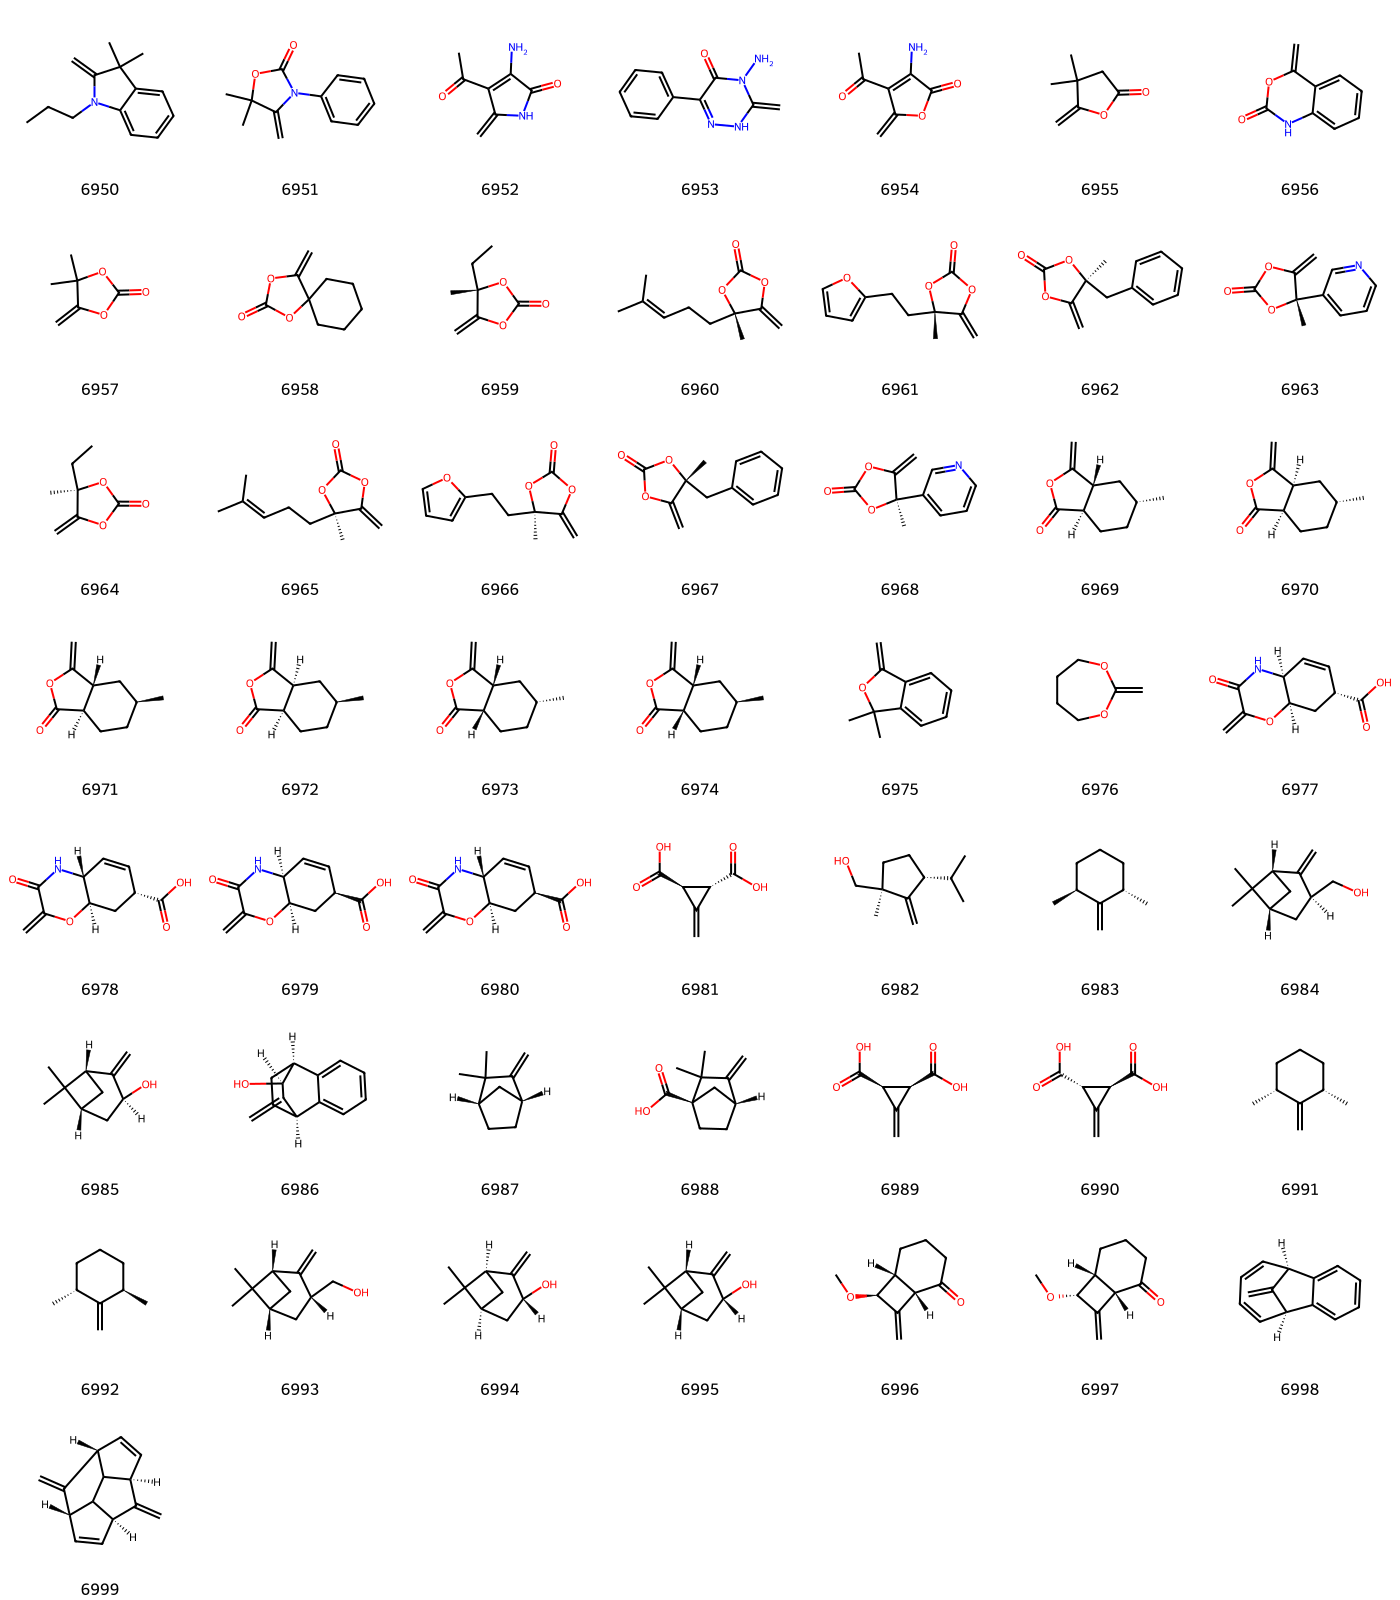

In [145]:
# first_id = 0
each_size = 50
first_id += each_size
Chem.Draw.MolsToGridImage(target_mols[first_id:first_id + each_size], molsPerRow=7, useSVG=1, legends=[str(each) for each in range(first_id, first_id + each_size)])

In [ ]:
target_dict = main.reaction_ts_result_analysis(r'E:\work\Secondary_Selection\6_Potential_BO', write_title=0, ts_eng_name='ts_eng_wb97mv', om_name='om_3')
target_dict

In [8]:
all_smiles_ids = set()
for row_id, row in target_dict.iterrows():
    diene_index = row['Diene_Index']
    ene_index = row['Ene_Index']
    for idx in [diene_index, ene_index]:
        if idx not in all_smiles_ids:
            all_smiles_ids.add(idx)
for smiles_id in list(all_smiles_ids):
    opt_files = glob.glob(rf"E:\work\Secondary_Selection\Diene_Ene_Smiles\mol_dft\smilesid_{smiles_id:05}*.log")
    for file_ in opt_files:
        shutil.move(file_, os.path.join(r'E:\work\Secondary_Selection\6_Potential_BO\reactant', os.path.basename(file_)))

In [10]:
row

Reaction_Index                                                     40
Diene_Index                                                     18097
Ene_Index                                                       18100
Product             [H]O[C@@]1([H])C([H])([H])C([H])([H])C([H])([H...
Title                                                    2 6 5 6 16 0
Structure_id                                                        3
product_G                                                DFT OPT Fail
product_E                                                         NaN
TS_G                                                      TS OPT Fail
TS_E                                                              NaN
deltaG                                                            NaN
deltaGa                                                           NaN
deltaE                                                            NaN
deltaEa                                                           NaN
conf_id             

In [69]:
final_energies = []
target_dict = pd.read_csv(r"E:\work\Secondary_Selection\6_Potential_BO\result_.csv")
for row_id, row in target_dict.iterrows():
    diene_index = row['Diene_Index']
    ene_index = row['Ene_Index']
    Structure_id = row['Structure_id']
    diene_log_files = glob.glob(rf"E:\work\Secondary_Selection\6_Potential_BO\reactant\smilesid_{diene_index:05}*.log")
    diene_eng = main.read_engs(diene_log_files, eng_dir=r'E:\work\Secondary_Selection\6_Potential_BO\reactant_eng_wb97mv')
    diene_eng = diene_eng[0][0]

    ene_log_files = glob.glob(rf"E:\work\Secondary_Selection\6_Potential_BO\reactant\smilesid_{ene_index:05}*.log")
    ene_eng = main.read_engs(ene_log_files, eng_dir=r'E:\work\Secondary_Selection\6_Potential_BO\reactant_eng_wb97mv')
    ene_eng = ene_eng[0][0]

    ts_log_files = glob.glob(rf"E:\work\Secondary_Selection\6_Potential_BO\ts\{diene_index:05}_{ene_index:05}_{Structure_id:05}*.log")
    if len(ts_log_files) == 0:
        final_energies.append(np.nan)
    else:
        ts_eng = main.read_engs(ts_log_files, eng_dir=r'E:\work\Secondary_Selection\6_Potential_BO\ts_eng_wb97mv')
        final_energies.append((ts_eng[0][0] - diene_eng - ene_eng) * 627.5)
target_dict['deltaGa(wB97mv)'] = final_energies
target_dict.to_csv(r"E:\work\Secondary_Selection\6_Potential_BO\result_wb97mv.csv", index=False)


In [45]:
final_csv = pd.read_csv(r"E:\work\All_BO_Prediction\BO_test_01\Result_.csv")
final_csv = final_csv.dropna(subset=['deltaGa(Solvent)'])
# final_csv = final_csv.loc[~np.isin(final_csv['Diene_Index'], unin_stock_idxs)]
# final_csv = final_csv.loc[~np.isin(final_csv['Ene_Index'], unin_stock_idxs)]
final_csv_ = final_csv.loc[final_csv.groupby(['Diene_Index', 'Ene_Index'])['deltaGa(Solvent)'].idxmin()]
# wb97mv_energy = final_csv.loc[final_csv.groupby(['Diene_Index', 'Ene_Index'])['deltaGa(wB97mv)'].idxmin()]['deltaGa(wB97mv)']
final_csv_.to_csv(r"E:\work\All_BO_Prediction\BO_test_01\Result_one.csv", index=False)

In [56]:
np.nan in final_csv.loc[final_csv.groupby(['Diene_Index', 'Ene_Index'])['deltaGa(wB97mv)'].idxmin()]['deltaGa(wB97mv)']

False

In [ ]:
root_dir = r"E:\work\Secondary_Selection\6_Potential_BO"

In [25]:
main.ts_SPE_DFT_calc(root_dir, ts_name='ts_new', eng_name = "ts_eng_solvent_new", method="b3lyp/6-311+g(d,p) em=gd3bj scrf=(smd, solvent=water)")

100%|██████████| 2/2 [00:00<00:00, 58.82it/s]


In [31]:
# Time Cost
import re
all_times = []
pattern = r'TOTAL RUN TIME:\s*(?P<days>\d+)\s*days\s*(?P<hours>\d+)\s*hours\s*(?P<minutes>\d+)\s*minutes\s*(?P<seconds>\d+)\s*seconds\s*(?P<msec>\d+)\s*msec'
time_to_min = lambda x: int(x[0])*24*60 + int(x[1])*60 + int(x[2]) + int(x[3])/60
for file_ in glob.glob(os.path.join(root_dir, "ts_eng_wb97mv", "*.out")):
    with open(file_, "rt") as f:
        for line in f.readlines():
            if "TOTAL RUN TIME" in line:
                time_line = line
                break
        match = re.search(pattern, time_line)
        time = time_to_min(match.groups())
        all_times.append(time)
np.mean(all_times)

9.884013605442176

In [73]:
final_csv = pd.read_csv(r"E:\work\Secondary_Selection\6_Potential_BO\result_wb97mv_one.csv")

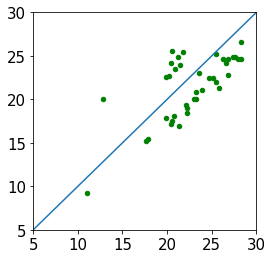

In [66]:
from matplotlib import pyplot as plt
plt.figure(figsize=(4,4))
plt.scatter(b3d3_energy, wb97mv_energy, c='green', s=20)
plt.plot([0,30], [0,30])
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlim(5,30)
plt.ylim(5,30)
plt.savefig('test.png', dpi=300, bbox_inches='tight')

In [74]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(final_csv['deltaGa(Solvent)'], final_csv['deltaGa(wB97mv)'])

2.9449858694358975

In [67]:
times = 0
for log_file in glob.glob(os.path.join(root_dir, "ts_eng_solvent", "*.log")):
    log = logfile_process.Logfile(log_file)
    times+=log.running_time
times / len(glob.glob(os.path.join(root_dir, "ts_eng_solvent", "*.log")))

1.6381938775510214